In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
def setup_mpl():
    mpl.rc('font', size = 9)
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['xtick.labelsize'] = 'small'
    mpl.rcParams['ytick.labelsize'] = 'small'
    mpl.rcParams['lines.linewidth'] = 1
    mpl.rcParams['xtick.major.width'] = 1
    mpl.rcParams['ytick.major.width'] = 1
    mpl.rcParams['xtick.minor.width'] = 1
    mpl.rcParams['ytick.minor.width'] = 1
    mpl.rcParams['xtick.major.size'] = 3
    mpl.rcParams['ytick.major.size'] = 3
    mpl.rcParams['xtick.minor.size'] = 1.5
    mpl.rcParams['ytick.minor.size'] = 1.5
    mpl.rcParams['axes.linewidth'] = 1
    mpl.rcParams['xtick.top'] = False
    mpl.rcParams['ytick.right'] = False
    mpl.rcParams['mathtext.default'] = 'regular'
    mpl.rcParams['xtick.major.pad'] = '2.3'
    mpl.rcParams['ytick.major.pad' ]= '2.3'
    mpl.rcParams['axes.labelpad'] = 2

setup_mpl()


In [16]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import h3
from tqdm import tqdm
from shapely.geometry import Polygon, Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import MinMaxScaler
import folium
import seaborn as sns
from scipy.stats import gaussian_kde
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import json
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

In [17]:

def h3_to_polygon(h3_hex):
    # Hex string to polygon
    coords = h3.h3_to_geo_boundary(h3_hex)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)

def get_data(countryID=None,case = "pre-covid"):
    countryname = dict_country[countryID]
    kind = "empirical"
    df = pd.read_csv("/work/netmob24/data/tmp/" + kind + "_" + case + "_" + countryname + ".csv")
    df["geometry"] = df["cell"].apply(h3_to_polygon)
    gdf_tmp = gpd.GeoDataFrame(df, geometry="geometry", crs = "EPSG:4326")
    case_mobility = "driving"
    df_driving = pd.read_csv("/work/netmob24/data/tmp/"+ case_mobility + "_"+countryname+".csv")
    gdf = pd.merge(gdf_tmp, df_driving, on = "cell",how ="inner")
    # Reorganize the data
    gdf = gdf.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
    gdf.rename(columns=dict_titles, inplace=True)
    gdf = pd.melt(gdf, id_vars=[case, case + '_cell', 'cell', 'geometry'],
                value_vars=['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', "2 h"],
                var_name='threshold', value_name=case+'_th')
    return gdf


def bootstrap_median(data, n_bootstrap=1000):
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    medians = np.median(bootstrap_samples, axis=1)
    median_estimate = np.mean(data)
    se_median = np.std(medians)
    return median_estimate, se_median

def weighted_median(values, weights):
    """Compute weighted median"""
    sorted_idx = np.argsort(values)
    sorted_vals = np.array(values)[sorted_idx]
    sorted_weights = np.array(weights)[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    cutoff = 0.5 * sum(sorted_weights)
    return sorted_vals[cum_weights >= cutoff][0]

In [18]:
dict_country = {
    "co":"colombia",
    "mx":"mexico",
    "in":"india",
    "id":"indonesia"
}

dict_titles = {
        "5000":"10 min",
        "7500":"15 min",
        "10000":"20 min",
        "15000":"30 min",
        "22500":"45 min",
        "30000":"1 h",
        "60000":"2 h"
}


In [19]:
gdf = gpd.read_file('/work/netmob24/data/cities/cities.geojson')
gdf = gdf[gdf['country'] != "colombia"]
cells2keep = gdf["cell"].unique()
gdf_info = gpd.read_file('/work/netmob24/data/cities/cities_info.geojson')
gdf = pd.merge(gdf, gdf_info.drop(columns=['geometry']), on = "name_city", how = "left")
cities = gdf["correct_name"].unique()
name_to_country = dict(zip(gdf['correct_name'], gdf['country']))

In [20]:
gdf = gdf[['cell', 'correct_name', 'country', 'pop_density', 'population', 'geometry']] # pop_density, population are at the city level

def lonlat_to_utm_epsg(lon, lat):
    """Infer UTM EPSG based on centroid lon/lat"""
    zone = int((lon + 180) / 6) + 1
    if lat >= 0:
        return 32600 + zone  # Northern Hemisphere
    else:
        return 32700 + zone  # Southern Hemisphere

def compute_city_compactness_auto_utm(gdf, city_col='city'):
    results = []

    # Ensure input is in WGS84
    gdf = gdf.to_crs("EPSG:4326")

    for city, city_gdf in gdf.groupby(city_col):
        # Compute centroid of all geometries
        centroid = city_gdf.geometry.unary_union.centroid
        lon, lat = centroid.x, centroid.y

        # Determine UTM EPSG
        epsg = lonlat_to_utm_epsg(lon, lat)

        # Project to local UTM CRS
        city_proj = city_gdf.to_crs(epsg=epsg)

        # Union of hexagons for this city
        geom_union = city_proj.geometry.unary_union

        # Compute area and perimeter
        area = geom_union.area
        perimeter = geom_union.length

        # Compactness
        compactness = (4 * np.pi * area) / (perimeter ** 2)

        results.append({
            city_col: city,
            'epsg': epsg,
            'area_m2': area,
            'perimeter_m': perimeter,
            'compactness': compactness
        })

    return gpd.GeoDataFrame(results)

def assign_compactness_cluster_within_country(group):
    median_c = group['compactness'].median()
    def cluster(row):
        if row['compactness'] <= median_c:
            return 1
        elif row['compactness'] > median_c:
            return 2

    group['Cluster'] = group.apply(cluster, axis=1)
    return group

def get_weekly_data(countryID=None):
    df1 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2019.csv")
    df2 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2020.csv")
    # Keep only pre-covid data
    df = pd.concat([df1, df2[df2["week_number"] < 10]], ignore_index=True)
    #only covid
    #df = df2[df2["week_number"] > 10].copy()
    # Focus on cities
    df = df[df["start_h3_7"].isin(cells2keep)]

    # Consider trips outside the focal cell
    # df = df[df["end_h3_7"] != df["start_h3_7"]]
    # Group and compute weighted medians
    result = df.groupby('start_h3_7').apply(
        lambda g: pd.Series({
            'wm_duration_min': weighted_median(g['m_duration_min'], g['trip_count']),
            'wm_length_m': weighted_median(g['mdn_length_m'], g['trip_count']) / 1000,  # Convert to km
        }), include_groups=False
    ).reset_index()
    return result.rename(columns={"start_h3_7": "cell"})

df_metrics = compute_city_compactness_auto_utm(gdf, city_col='correct_name')
df_metrics = pd.merge(df_metrics[['correct_name', 'compactness']], 
                      gdf[['correct_name', 'country', 'pop_density', 'population']].drop_duplicates(subset=['correct_name']), 
                      left_on='correct_name', right_on='correct_name', how='left')


df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)

cluster_name_dict = {
    2: "Compact",
    1: "Sparse",
}
df_metrics_c['Cluster_c'] = df_metrics_c['Cluster'].map(cluster_name_dict)

In [21]:
def add_deprivation_groups_residential_th_interq(gdf=None, num_grp=None,case = "pre-covid"):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, case+'_cell'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        return pd.Series(dict(d_50_r=data[case+"_cell"].median(),
                            d_25_r=data[case+"_cell"].quantile(0.25),
                            d_75_r=data[case+"_cell"].quantile(0.75),
                            d_50_th=data[case+"_th"].median(),
                            d_25_th=data[case+"_th"].quantile(0.25),
                            d_75_th=data[case+"_th"].quantile(0.75),
                            d_50=data[case].median(),
                            d_25=data[case].quantile(0.25),
                            d_75=data[case].quantile(0.75)))
    gdf_g = gdf.groupby(['grp_cell', 'threshold']).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g
def add_deprivation_groups_residential_th_md(gdf=None, num_grp=None,case = "pre-covid"):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, case+'_cell'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_r, md_err_r = bootstrap_median(data[case+"_cell"], n_bootstrap=1000)
        md_th, md_err_th = bootstrap_median(data[case+"_th"], n_bootstrap=1000)
        md, md_err = bootstrap_median(data[case], n_bootstrap=1000)
        return pd.Series(dict(d_50_r=md_r,
                              d_err_r = md_err_r,
                              d_50_th=md_th,
                              d_err_th=md_err_th,
                              d_50=md,
                              d_err=md_err))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def deprivation_exposure_data(countryID=None):
    gdf = get_data(countryID=countryID)
    return add_deprivation_groups_residential_th_md(gdf=gdf, num_grp=30)

def get_data_gap(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'Bubble Breaking Gap PRE'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["gap"], n_bootstrap=1000)
        return pd.Series(dict(r=data["Bubble Breaking Gap PRE"].median(),
                              gap_50=md_e,
                              gap_err=md_err_e))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def get_data_residential(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'Residential'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["gap"], n_bootstrap=1000)
        return pd.Series(dict(r=data["Residential"].median(),
                              gap_50=md_e,
                              gap_err=md_err_e))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def get_data_post_vs_pre(countryID):
    gdf_original = get_data(countryID=countryID)
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_t'] = -gdf_original.loc[:, 'Theoretical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_g'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Theoretical']
    pre_covid = gdf_original
    #
    case = "post-covid"
    gdf_original = get_data(countryID=countryID,case = case)
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={case: 'Empirical', case+'_cell': 'Residential', case+'_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_t'] = -gdf_original.loc[:, 'Theoretical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_g'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Theoretical']
    post_covid = gdf_original
    #
    pre_covid.rename(columns={"bb_g":"Bubble Breaking Gap PRE"},inplace = True)
    post_covid.rename(columns={"bb_g":"Bubble Breaking Gap POST"},inplace = True)
    pre_covid = pre_covid[["cell","Bubble Breaking Gap PRE","threshold","Residential"]]
    post_covid = post_covid[["cell","Bubble Breaking Gap POST","threshold"]]
    #
    df = pd.merge(pre_covid,post_covid,how = "left", on = ["cell","threshold"])
    return df

In [22]:
threshold = '45 min'

agg_columns = ['Present after COVID?',"Bubble Breaking Gap POST","Bubble Breaking Gap PRE",'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini']


def city_agg(x):
    res = dict()
    for var in agg_columns:
        if var == 'Present after COVID?':
            n = (x["Present after COVID?"] == False).sum()
            p = (x["Present after COVID?"] == True).sum()
            res["Fraction of Cells Not Present"] = n/(p+n)
        else:
            clean_sample = x[var].dropna()
            res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(clean_sample, n_bootstrap=1000)
    return pd.Series(res)

df_cities = []
df_raw = []
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    file_path = "../data/population/population.json"
    # Load JSON as a Python dictionary
    with open(file_path, "r", encoding="utf-8") as f:
        pop_dict = json.load(f)
    df = get_data_post_vs_pre(countryID=countryID)
    df["Present after COVID?"] = ~df["Bubble Breaking Gap POST"].isna()
    gdf_original = df[df['threshold']==threshold]
    gdf_original = pd.merge(gdf_original, gdf[['cell', 'country', 'correct_name']], on = "cell", how = "left")
    #Add POI
    gdf_original.loc[:, 'pop'] = gdf_original.loc[:, 'cell'].map(pop_dict)
    gdf_original.dropna(inplace=True,subset = ["pop"])
    gdf_original = pd.merge(gdf_original, get_weekly_data(countryID=countryID), on = "cell", how = "left")

    df_poi = pd.read_csv(f"../data/pois/pois_{dict_country[countryID]}_cell.csv", usecols=['cell', 'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini'])
    
    gdf_original = pd.merge(gdf_original, df_poi, on = "cell", how = "left")
    gdf_original.loc[:, 'POI density'] = gdf_original.loc[:, 'Number of POI'] / gdf_original.loc[:, 'pop']  # POI density

    df_raw.append(gdf_original)
    # Group and aggregate
    agg_df = gdf_original.groupby('correct_name')[agg_columns].apply(city_agg).reset_index()

    # Flatten column names
    # agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    agg_df.loc[:, 'country'] = dict_country[countryID].capitalize()
    df_cities.append(agg_df)
df_cities = pd.concat(df_cities, ignore_index=True)
df_raw = pd.concat(df_raw, ignore_index=True)
df_raw.rename(columns={'country': 'Country'}, inplace=True)
df_cities = pd.merge(df_cities, gdf_info[['correct_name', 'pop_density','population']], on = ["correct_name"], how = "left")
df_cities.rename(columns={'country': 'Country'}, inplace=True)

In [23]:
ds = []
countries = ["mexico","india"]
for countryname in countries:
    tmp_df_detour = pd.read_csv("../data/detour/"+countryname+".csv",sep = ",")
    ds.append(tmp_df_detour)
df_detour = pd.concat(ds)
df_raw = pd.merge(df_detour, df_raw, on='cell', how='left')

In [24]:
df_raw = df_raw.merge(df_metrics_c[['correct_name', 'Cluster_c']], on='correct_name', how='left')
df_raw.head()

,cell,detour,Bubble Breaking Gap PRE,threshold,Residential,Bubble Breaking Gap POST,Present after COVID?,Country,correct_name,pop,wm_duration_min,wm_length_m,Number of POI,Number of Unique Categories,Entropy,Gini,POI density,Cluster_c
0,874995b86ffffff,1.210166,1.756957,45 min,12.554252,2.281233,True,mexico,Greater Mexico City,86480.771429,45.253772,0.365647,390.0,26.0,3.693287,0.875411,0.004510,Sparse
1,874995bb1ffffff,1.223314,0.608739,45 min,8.820479,0.860058,True,mexico,Greater Mexico City,85872.885714,43.445370,0.355938,444.0,23.0,3.741544,0.900252,0.005170,Sparse
2,874995ba6ffffff,1.207564,1.266954,45 min,6.710177,2.240042,True,mexico,Greater Mexico City,89520.742857,52.252239,2.344003,804.0,26.0,4.080531,0.923266,0.008981,Sparse
3,874995ba2ffffff,1.208923,0.982073,45 min,8.479541,1.969261,True,mexico,Greater Mexico City,83972.825000,46.948280,0.377496,680.0,24.0,4.075617,0.927288,0.008098,Sparse
4,874995bb5ffffff,1.241095,1.423002,45 min,8.058673,1.926086,True,mexico,Greater Mexico City,88536.475000,57.034581,2.180986,419.0,26.0,4.080046,0.925718,0.004733,Sparse


In [25]:
df_metrics_plot = pd.merge(df_metrics_c[['correct_name', 'Cluster_c']],df_cities, how='inner')

In [26]:
cluster_markers = {
    'Compact': 'o',  # Circle
    'Sparse': '^',  # Triangle
}
colors={"Compact": "darkorange", "Sparse": "rebeccapurple"}
df_metrics_plot["color"] = df_metrics_plot["Cluster_c"].map(colors)
df_metrics_plot["Marker"] = df_metrics_plot["Cluster_c"].map(cluster_markers)

In [27]:
df_metrics_plot["size"] = df_metrics_plot["Bubble Breaking Gap PRE_md"]
df_metrics_plot.loc[df_metrics_plot["size"] < 0,"size"] = 1
df_metrics_plot["Fraction of Cells Not Present"].describe()

count    64.000000
mean      0.569486
std       0.131560
min       0.285714
25%       0.473579
50%       0.569867
75%       0.670455
max       0.812500
Name: Fraction of Cells Not Present, dtype: float64

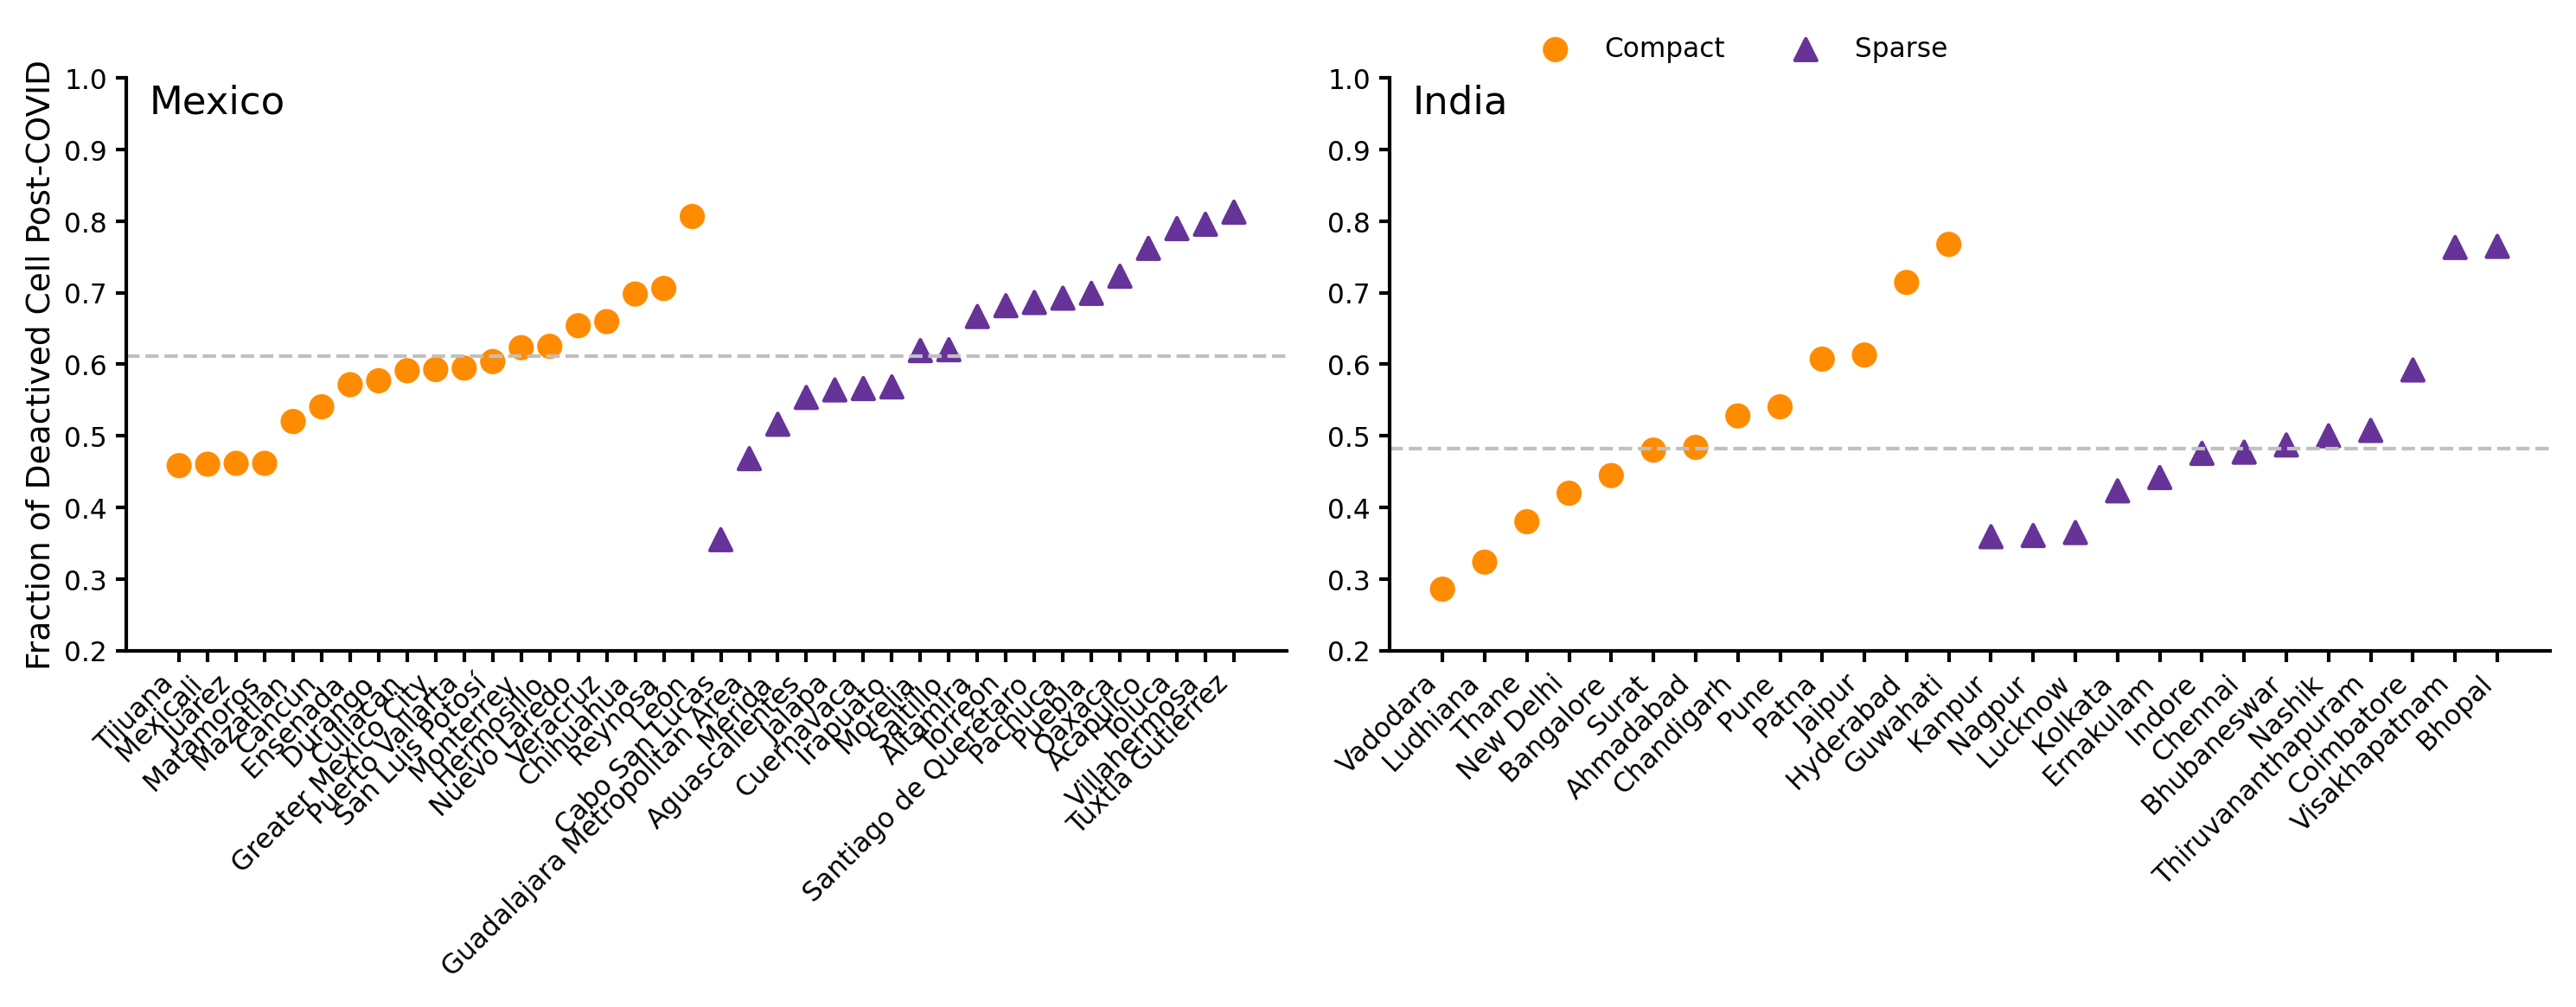

In [29]:
fig = plt.figure(figsize=(10,4), dpi=300)
countries = ['Mexico', 'India']
for idx, country in enumerate(countries, 1):
    ax = fig.add_subplot(1, 2, idx)
    df = df_metrics_plot[df_metrics_plot["Country"] == country]
    df = df.sort_values(by=["Fraction of Cells Not Present"])

    for cluster, marker in cluster_markers.items():
        cluster_data = df[df["Cluster_c"] == cluster]
        if country == "Mexico":
            ax.scatter(
                    cluster_data["correct_name"],
                    cluster_data["Fraction of Cells Not Present"],
                    #s=3*cluster_data["size"],
                    color = cluster_data["color"],
                    marker=marker,
                    label=f"{cluster}")
        else:
            ax.scatter(
                    cluster_data["correct_name"],
                    cluster_data["Fraction of Cells Not Present"],
                    #s=9*cluster_data["size"],
                    color = cluster_data["color"],
                    marker=marker,
                    label=f"{cluster}")


    ax.set_xticks(range(len(df["correct_name"])))
    ax.set_xticklabels(df["correct_name"], rotation=45, ha='right')
    ax.set_ylim([0.2, 1.0])
    ax.text(0.02, 0.99, country,
            transform=ax.transAxes,
            fontsize=ax.title.get_fontsize(),  # or a fixed size, e.g. 12
            verticalalignment='top',
            horizontalalignment='left',
            bbox=None)
    if idx == 2:
        ax.legend(bbox_to_anchor = [0.3,1.05],loc = "center",ncol = 2,frameon = False)
    if idx == 1:
        ax.set_ylabel("Fraction of Deactived Cell Post-COVID")
    ax.axhline(df["Fraction of Cells Not Present"].median(),color = "silver",ls = "dashed")
    sns.despine()
fig.tight_layout()
fig.savefig("figure/supplementary_fig_a.pdf",bbox_inches = "tight",dpi = 300)